# Variant 1 — BERT Fine-Tuning for Sentiment Classification
**DS4 ACT4 — Multi-Variant Text Analysis and Generation**
Group 1, CSS182-04 CM2

This notebook fine-tunes `bert-base-uncased` on the cleaned Twitter Financial News Sentiment
splits produced by `00_preprocessing.ipynb`. The task is 3-class sequence classification
(Bearish / Bullish / Neutral). We report Precision, Recall, and F1-score per class and macro-averaged,
plus a confusion matrix, so the result can be compared against the GPT and GAN variants in the
final performance matrix.

In [16]:
# Colab convenience install — comment out if running locally with requirements.txt already installed
# !pip install -q transformers datasets evaluate scikit-learn accelerate


In [17]:
# Core imports used throughout this notebook
import os                                                  # filesystem paths for saving results
import json                                                # saving the training history as json
from pathlib import Path                                      # robust project-relative paths
import numpy as np                                         # numerical ops on logits / labels
import pandas as pd                                        # reading the shared CSV splits
import matplotlib.pyplot as plt                             # plotting loss/accuracy curves
import seaborn as sns                                       # confusion matrix heatmap
import torch                                                # tensor backend used by Transformers

from datasets import Dataset                                # wraps our pandas splits as HF Datasets
from transformers import (
    BertTokenizerFast,                                      # fast WordPiece tokenizer for BERT
    BertForSequenceClassification,                          # BERT + classification head
    TrainingArguments,                                      # training hyperparameters container
    Trainer,                                                # high-level training loop
    EarlyStoppingCallback,                                  # stop training once val loss plateaus
)
from sklearn.metrics import (
    precision_recall_fscore_support,                        # per-class P/R/F1
    accuracy_score,                                          # overall accuracy
    confusion_matrix,                                        # for the confusion matrix plot
    classification_report,                                   # readable per-class summary
)

SEED = 42                                                   # fixed seed for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # prefer GPU (Colab T4)
print(f"Using device: {device}")


Using device: cuda


## 1. Load the shared preprocessed splits
These CSVs were produced once by `00_preprocessing.ipynb` so every variant trains/evaluates on the exact same rows.

In [18]:

# Resolve paths robustly whether the notebook is launched from the repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dataset").exists() and (PROJECT_ROOT.parent / "dataset").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "results"

# Load the shared splits exported by the preprocessing notebook
train_df = pd.read_csv(DATA_DIR / "train.csv")              # training split
val_df   = pd.read_csv(DATA_DIR / "val.csv")                # validation split (model selection)
test_df  = pd.read_csv(DATA_DIR / "test.csv")               # held-out test split (final metrics)

# Avoid tokenizer errors if a cleaned tweet is missing.
for df in (train_df, val_df, test_df):
    df["clean_text"] = df["clean_text"].fillna("").astype(str)
    df["label"] = df["label"].astype(int)

# label_map kept identical to preprocessing notebook: 0=Bearish, 1=Bullish, 2=Neutral
LABEL_NAMES = ["Bearish", "Bullish", "Neutral"]
NUM_LABELS = len(LABEL_NAMES)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df[["clean_text", "label", "sentiment"]].head()


Train: 9425 | Val: 1194 | Test: 1194


,clean_text,label,sentiment
0,<STOCK> - JPMorgan reels in expectations on Be...,0,Bearish
1,<STOCK> <STOCK> - Nomura points to bookings we...,0,Bearish
2,"<STOCK> - Cemex cut at Credit Suisse, J.P. Mor...",0,Bearish
3,<STOCK>: BTIG Research cuts to Neutral,0,Bearish
4,<STOCK> - Funko slides after Piper Jaffray PT cut,0,Bearish


## 2. Tokenization
We tokenize the `clean_text` column (URLs/mentions/emoji already stripped) with the BERT WordPiece tokenizer, padding/truncating to a fixed max length chosen from the token-length EDA in the preprocessing notebook.

In [19]:
# Load the pretrained tokenizer that matches bert-base-uncased
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

MAX_LEN = 64                                                 # tweets are short; covers the vast majority per EDA histogram

def tokenize_batch(batch):
    # tokenizes a batch of cleaned tweets with fixed padding/truncation
    return tokenizer(
        batch["clean_text"],
        padding="max_length",                                # pad every example to MAX_LEN
        truncation=True,                                      # truncate anything longer than MAX_LEN
        max_length=MAX_LEN,
    )

# Wrap each pandas split as a HuggingFace Dataset, keeping only what we need
train_ds = Dataset.from_pandas(train_df[["clean_text", "label"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[["clean_text", "label"]].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[["clean_text", "label"]].reset_index(drop=True))

# Apply tokenization across each split
train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds   = val_ds.map(tokenize_batch, batched=True)
test_ds  = test_ds.map(tokenize_batch, batched=True)

# Rename label -> labels so the Trainer's loss computation finds it automatically
train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")

# Set the tensor format so batches come out as torch tensors
columns = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=columns)
val_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)


Map: 100%|██████████| 1194/1194 [00:00<00:00, 17203.41 examples/s]


## 3. Class weighting
The sentiment classes are imbalanced (Neutral dominates). We reuse the `class_weights.npy` saved by the preprocessing notebook so all three variants account for imbalance consistently.

In [20]:

# Load the class weights computed once during preprocessing
class_weights = np.load(RESULTS_DIR / "class_weights.npy")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights (Bearish, Bullish, Neutral):", class_weights)


Class weights (Bearish, Bullish, Neutral): [2.20004669 1.6483036  0.51578832]


## 4. Model definition
`BertForSequenceClassification` with `num_labels=3`. We subclass `Trainer` to inject the weighted cross-entropy loss so minority classes are not ignored.

In [21]:
# Load pretrained BERT with a fresh classification head sized for our 3 sentiment classes
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=NUM_LABELS,
).to(device)

class WeightedTrainer(Trainer):
    # Overrides the default loss to use class-weighted cross-entropy
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")                        # extract ground-truth labels
        outputs = model(**inputs)                             # forward pass
        logits = outputs.logits                                # raw class scores
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)  # weighted loss
        loss = loss_fct(logits.view(-1, NUM_LABELS), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3479.23it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

## 5. Metrics function
Computes accuracy plus per-class and macro-averaged Precision/Recall/F1 on each evaluation pass, matching the comparison matrix required by the activity brief.

In [22]:
def compute_metrics(eval_pred):
    # Standard HF-style metrics callback used by the Trainer at each evaluation step
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)                         # convert logits to predicted class ids

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    per_class_p, per_class_r, per_class_f1, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }
    # also log per-class F1 so we can see which sentiment class struggles most
    for i, name in enumerate(LABEL_NAMES):
        metrics[f"f1_{name.lower()}"] = per_class_f1[i]
    return metrics


## 6. Training arguments and callbacks
Standard callbacks: `EarlyStoppingCallback` to avoid overfitting once validation F1 stops improving.

In [23]:
training_args = TrainingArguments(
    output_dir=str(RESULTS_DIR / "bert_checkpoints"),                # where checkpoints are written
    num_train_epochs=4,                                       # upper bound; early stopping may cut this short
    per_device_train_batch_size=16,                            # batch size tuned for a T4 GPU
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                                         # standard BERT fine-tuning LR
    weight_decay=0.01,                                          # mild L2 regularization
    warmup_ratio=0.1,                                           # linear warmup over first 10% of steps
    eval_strategy="epoch",                                      # evaluate once per epoch
    save_strategy="epoch",                                      # checkpoint once per epoch
    load_best_model_at_end=True,                                # restore best checkpoint after training
    metric_for_best_model="f1_macro",                           # select best epoch by macro F1
    greater_is_better=True,
    logging_dir=str(RESULTS_DIR / "bert_logs"),
    logging_steps=50,
    seed=SEED,
    report_to="none",                                           # disable wandb/tensorboard auto-logging
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],  # stop after 2 epochs with no F1 improvement
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 7. Train
Timing is captured around the call so we can report training time per epoch in the final comparison matrix.

In [24]:
import time

start = time.time()                                           # start the per-epoch timing
train_result = trainer.train()                                 # run the fine-tuning loop
elapsed = time.time() - start

n_epochs_run = trainer.state.epoch                              # actual epochs completed (early stopping aware)
time_per_epoch = elapsed / max(n_epochs_run, 1)

print(f"Total training time: {elapsed/60:.2f} min over {n_epochs_run:.1f} epochs")
print(f"Average time/epoch : {time_per_epoch:.1f} sec")


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Bearish,F1 Bullish,F1 Neutral
1,0.510778,0.428387,0.842546,0.774909,0.835822,0.800017,0.739946,0.766798,0.893307
2,0.367262,0.411166,0.884422,0.834015,0.863966,0.846580,0.786280,0.829596,0.923864
3,0.198185,0.450662,0.885260,0.841584,0.859291,0.849955,0.795389,0.834043,0.920433
4,0.071161,0.565655,0.889447,0.849854,0.859736,0.854694,0.796562,0.844639,0.922882


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.45s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

Total training time: 6.31 min over 4.0 epochs
Average time/epoch : 94.6 sec


## 8. Training history plot
Loss/accuracy curves saved as both PNG and CSV per the repo's `results/training_histories/` convention.

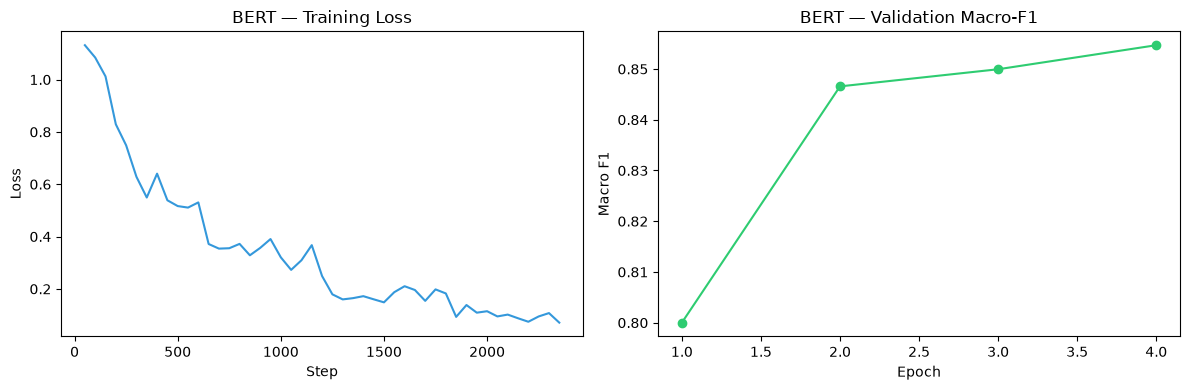

In [25]:
# Pull the per-logging-step history out of the Trainer's log object
log_history = trainer.state.log_history
hist_df = pd.DataFrame(log_history)

history_dir = RESULTS_DIR / "training_histories"
history_dir.mkdir(parents=True, exist_ok=True)
hist_df.to_csv(history_dir / "bert_training_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training loss curve (logged every `logging_steps`)
train_loss = hist_df.dropna(subset=["loss"]) if "loss" in hist_df else pd.DataFrame()
if not train_loss.empty:
    axes[0].plot(train_loss["step"], train_loss["loss"], color="#3498db")
    axes[0].set_title("BERT — Training Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")

# Validation macro-F1 curve (logged once per epoch)
eval_f1 = hist_df.dropna(subset=["eval_f1_macro"]) if "eval_f1_macro" in hist_df else pd.DataFrame()
if not eval_f1.empty:
    axes[1].plot(eval_f1["epoch"], eval_f1["eval_f1_macro"], marker="o", color="#2ecc71")
    axes[1].set_title("BERT — Validation Macro-F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro F1")

plt.tight_layout()
plt.savefig(history_dir / "bert_training_curves.png", dpi=150)
plt.show()


## 9. Final evaluation on the held-out test set
This is the number that goes into the comparison matrix: per-class and macro Precision/Recall/F1.

In [26]:
test_output = trainer.predict(test_ds)                          # run inference over the test split
test_logits = test_output.predictions
test_labels = test_output.label_ids
test_preds  = np.argmax(test_logits, axis=1)

print(classification_report(test_labels, test_preds, target_names=LABEL_NAMES, digits=4))

# Save the structured metrics for the cross-notebook comparison matrix
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average="macro", zero_division=0)
bert_metrics = {
    "model": "BERT (bert-base-uncased)",
    "task": "3-class sentiment classification",
    "accuracy": float(accuracy_score(test_labels, test_preds)),
    "precision_macro": float(precision),
    "recall_macro": float(recall),
    "f1_macro": float(f1),
    "time_per_epoch_sec": float(time_per_epoch),
}
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / "bert_metrics.json", "w") as f:
    json.dump(bert_metrics, f, indent=2)

bert_metrics


              precision    recall  f1-score   support

     Bearish     0.7744    0.8629    0.8162       175
     Bullish     0.8395    0.8193    0.8293       249
     Neutral     0.9233    0.9065    0.9148       770

    accuracy                         0.8819      1194
   macro avg     0.8457    0.8629    0.8534      1194
weighted avg     0.8840    0.8819    0.8825      1194



{'model': 'BERT (bert-base-uncased)',
 'task': '3-class sentiment classification',
 'accuracy': 0.8819095477386935,
 'precision_macro': 0.8457151901596346,
 'recall_macro': 0.8628759192614615,
 'f1_macro': 0.853431489860221,
 'time_per_epoch_sec': 94.62519299983978}

## 10. Confusion matrix

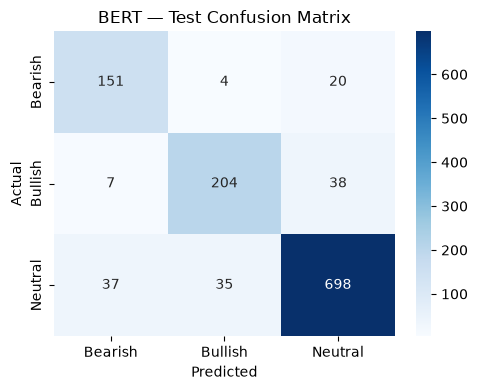

In [27]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT — Test Confusion Matrix")
plt.tight_layout()
figures_dir = RESULTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "bert_confusion_matrix.png", dpi=150)
plt.show()


## 11. Save predictions and sample outputs
Matches the `results/sample_outputs/bert_test_predictions.csv` path referenced in the README's quickstart shortcuts.

In [28]:
sample_dir = RESULTS_DIR / "sample_outputs"
sample_dir.mkdir(parents=True, exist_ok=True)

pred_df = test_df[["text", "clean_text", "sentiment"]].copy()
pred_df["predicted_label_id"] = test_preds
pred_df["predicted_sentiment"] = pred_df["predicted_label_id"].map(dict(enumerate(LABEL_NAMES)))
pred_df["correct"] = pred_df["sentiment"] == pred_df["predicted_sentiment"]

pred_df.to_csv(sample_dir / "bert_test_predictions.csv", index=False)
print(f"Saved {len(pred_df)} predictions -> {sample_dir / 'bert_test_predictions.csv'}")
pred_df.head(10)


Saved 1194 predictions -> c:\Users\dusti\Documents\Code\DS4\DS4_ACT4_MVTAnalysisNGeneration\results\sample_outputs\bert_test_predictions.csv


,text,clean_text,sentiment,predicted_label_id,predicted_sentiment,correct
0,Lupin reports Q3 results,Lupin reports Q3 results,Neutral,2,Neutral,True
1,"$ABEO as expected, keeps going higher. Cantor ...","<STOCK> as expected, keeps going higher. Canto...",Bullish,1,Bullish,True
2,Is Seritage Growth Properties (SRG) A Good Sto...,Is Seritage Growth Properties (SRG) A Good Sto...,Neutral,2,Neutral,True
3,$BPIRY $BPIRD $BPIRF - Piraeus Bank reports Q3...,<STOCK> <STOCK> <STOCK> - Piraeus Bank reports...,Neutral,2,Neutral,True
4,Qatar began marketing U.S. dollar-denominated ...,Qatar began marketing U.S. dollar-denominated ...,Neutral,1,Bullish,False
5,Governments are now using the fine print of fi...,Governments are now using the fine print of fi...,Neutral,2,Neutral,True
6,Trump budget would cut loan program used by Te...,Trump budget would cut loan program used by Te...,Neutral,2,Neutral,True
7,Europe is set to stake its economic future on ...,Europe is set to stake its economic future on ...,Neutral,2,Neutral,True
8,The U.S. and China are reportedly taking steps...,The U.S. and China are reportedly taking steps...,Neutral,2,Neutral,True
9,$JAN (+92.2% pre) JanOne entered into a Patent...,<STOCK> (+92.2% pre) JanOne entered into a Pat...,Bullish,1,Bullish,True


## 12. BERT Results Discussion

The BERT variant performed well on the three-class financial sentiment classification task. On the held-out test set, the model achieved an accuracy of **0.8819**, macro precision of **0.8457**, macro recall of **0.8629**, and macro F1-score of **0.8534**. These results indicate that the model was able to learn meaningful sentiment patterns from the cleaned financial tweet corpus.

The macro F1-score is especially important for this dataset because the sentiment classes are imbalanced. A high overall accuracy alone could be misleading if the model mostly predicted the majority class. Since the macro F1-score averages performance across Bearish, Bullish, and Neutral classes equally, the score of **0.8534** suggests that BERT performed reasonably well across all sentiment categories rather than only learning the dominant Neutral class.

## 13. Confusion Matrix Interpretation

The confusion matrix shows that BERT classified most test examples correctly. Out of the test set, the model correctly predicted **151 Bearish**, **204 Bullish**, and **698 Neutral** examples. The strongest class by raw count was Neutral, which is expected because Neutral tweets appear most frequently in the dataset.

Most classification errors happened in the Neutral class. There were **72 Neutral tweets** misclassified as either Bearish or Bullish. This makes sense because financial tweets can contain company names, analyst actions, price movement terms, or market events without clearly expressing positive or negative sentiment. Some Neutral tweets may therefore look similar to Bullish or Bearish examples at the token level.

The Bullish class had **45 errors**, while the Bearish class had **24 errors**. Bullish tweets were sometimes confused with Neutral, likely because some positive financial events are written in a factual news style rather than using clearly positive language. Bearish tweets had fewer total errors, suggesting that negative financial signals may have been easier for the model to detect when words related to cuts, weakness, losses, or downgrades appeared.

## 14. Tokenization and Class Weighting Effects

BERT uses WordPiece tokenization, which helps it handle financial vocabulary, stock tickers, company names, abbreviations, and unusual tweet text by breaking rare words into smaller subword units. This is useful for noisy financial social media data because the model can still represent unfamiliar terms instead of treating every unknown word as a single out-of-vocabulary token.

However, tokenization can also make the task harder when tweets contain short fragments, ticker symbols, or heavily abbreviated language. A short tweet may only contain a few meaningful tokens, so if those tokens are split into multiple subwords, the model has less clear semantic context than it would in a full sentence or article.

Class weighting was used to reduce the effect of class imbalance. Since Neutral examples are more common than Bearish and Bullish examples, a normal loss function could bias the model toward predicting Neutral too often. The weighted loss gives more importance to minority classes, helping the model improve macro-level performance instead of optimizing only for overall accuracy.

## 15. BERT Variant Summary

Overall, the BERT variant produced strong classification results for financial tweet sentiment analysis. The model achieved high accuracy and a solid macro F1-score, showing that it was effective at distinguishing Bearish, Bullish, and Neutral tweets after fine-tuning.

The remaining errors mostly came from ambiguous or factual financial tweets, where the sentiment signal is not always explicit. This limitation is expected for short-form financial text because market-related language can be subtle, context-dependent, or neutral in tone even when it mentions important company events.

For this notebook, BERT is best interpreted as a strong discriminative model. It does not generate new text, but it performs well at understanding and categorizing existing text. This makes precision, recall, F1-score, accuracy, and the confusion matrix the most appropriate evaluation tools for this variant.


## References

* **Model Architecture:** Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. arXiv preprint arXiv:1810.04805. [https://arxiv.org/abs/1810.04805](https://arxiv.org/abs/1810.04805)
* **Framework:** Wolf, T., Debut, L., Sanh, V., Chaumond, J., Delangue, C., Moi, A., ... & Rush, A. M. (2020). *Transformers: State-of-the-Art Natural Language Processing*. In Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing: System Demonstrations (pp. 38-45). 
* **Evaluation Metrics:** Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.